[**************        29%                       ]  2 of 7 completed

📥 Downloading historical price data...


[*********************100%***********************]  7 of 7 completed


✅ Data downloaded: 1258 trading days x 7 assets

📊 Last 5 rows of price data:
Ticker             AMD         CVX       INTC         JNJ         JPM  \
Date                                                                    
2023-12-22  139.600006  135.811127  47.365639  144.608780  157.864838   
2023-12-26  143.410004  137.033936  49.832600  145.241333  158.798477   
2023-12-27  146.070007  136.584366  50.089165  145.436707  159.750931   
2023-12-28  148.759995  134.660263  49.724052  145.650604  160.599655   
2023-12-29  147.410004  134.111801  49.585903  145.799438  160.411057   

Ticker            META         UNH  
Date                                
2023-12-22  350.313690  493.301910  
2023-12-26  351.741119  493.036530  
2023-12-27  354.714996  495.653259  
2023-12-28  355.200775  497.653717  
2023-12-29  350.878723  499.142151  

📈 Calculating daily returns...
✅ Returns calculated: 1257 trading days

📊 Sample of daily returns:
Ticker           AMD       CVX      INTC       JNJ 

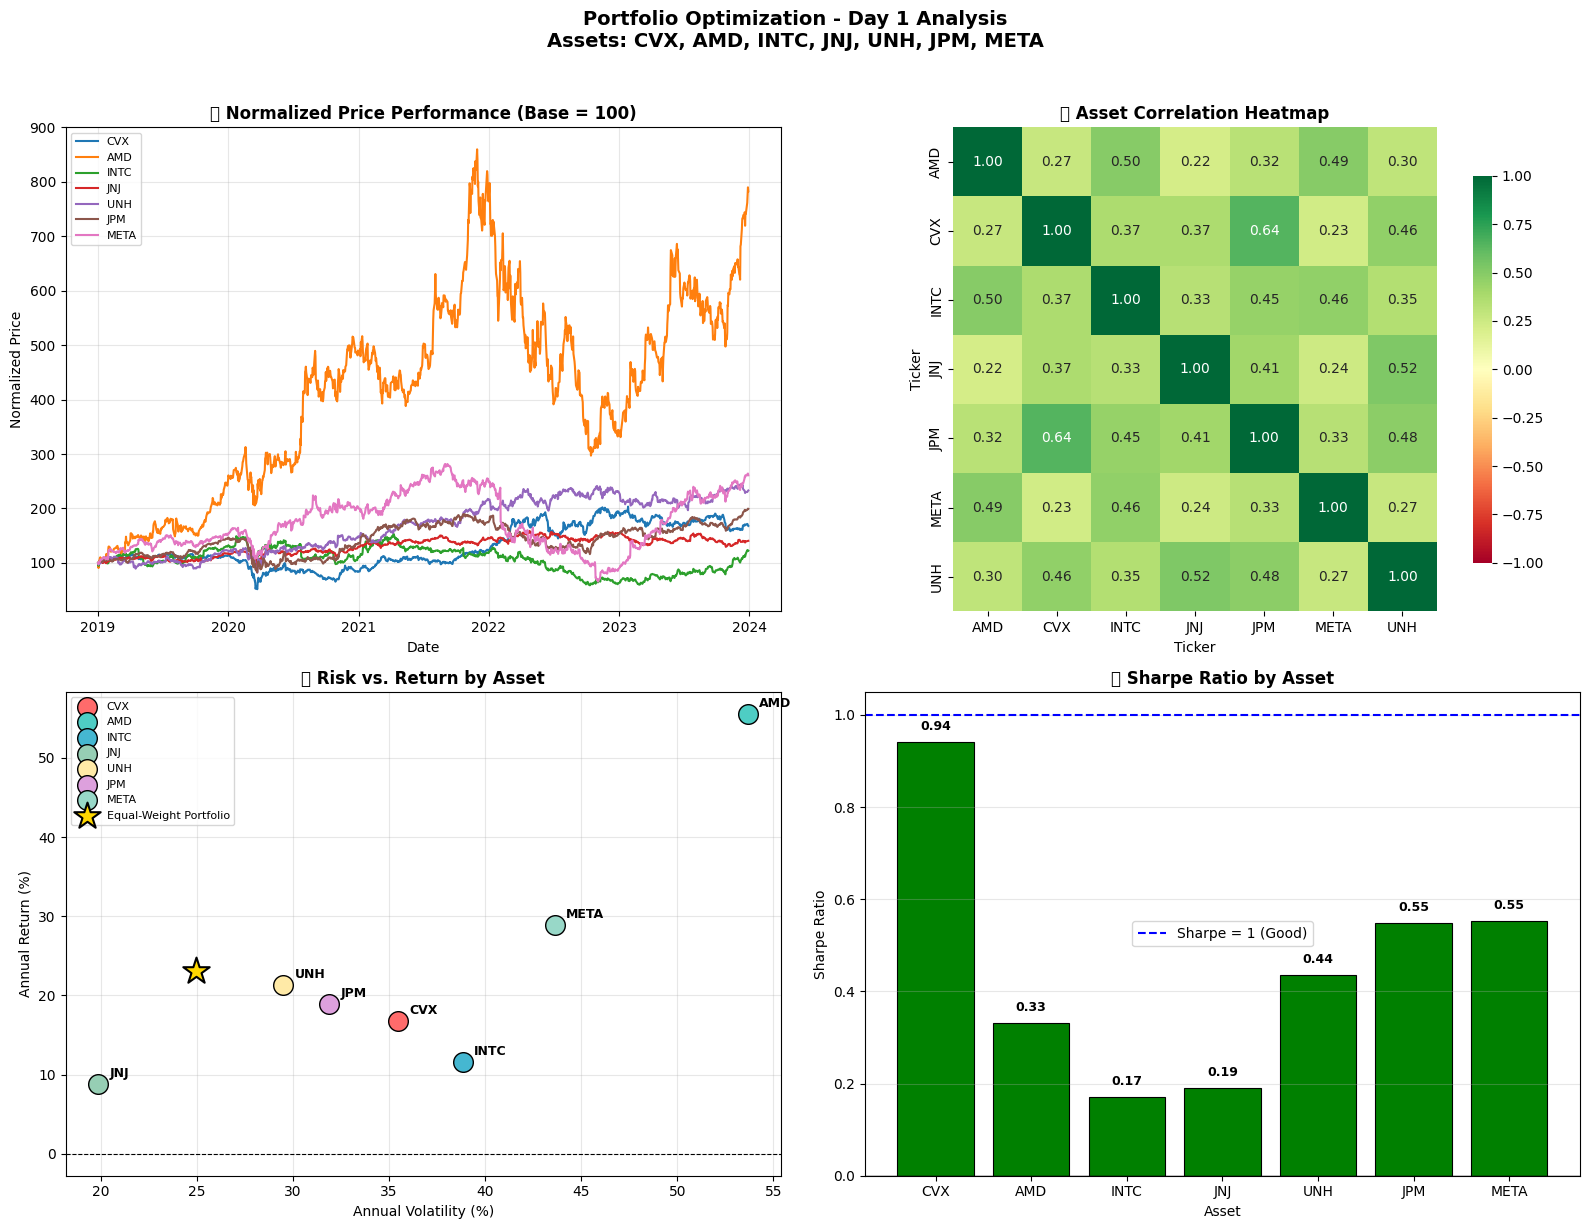

✅ Chart saved as 'portfolio_day1_analysis.png'

📋 DAY 1 COMPLETE - SUMMARY
✅ Assets Analyzed     : CVX, AMD, INTC, JNJ, UNH, JPM, META
✅ Date Range          : 2019-01-01 to 2024-01-01
✅ Trading Days        : 1257
✅ Risk-Free Rate      : 5.0%
-------------------------------------------------------
🏆 Best Sharpe Ratio   : AMD (0.942)
📈 Highest Return      : AMD (55.56%)
🛡️  Lowest Volatility  : JNJ (19.86%)
-------------------------------------------------------
⭐ Equal-Weight Portfolio Sharpe : 0.726
📈 Equal-Weight Portfolio Return : 23.12%
📉 Equal-Weight Portfolio Risk   : 24.95%

🚀 Ready for Day 2: Monte Carlo Simulation & Efficient Frontier!


In [2]:
# ============================================================
# PORTFOLIO OPTIMIZATION - DAY 1
# Assets: CVX, AMD, INTC, JNJ, UNH, JPM, META
# Modern Portfolio Theory - Data Collection & Risk Metrics
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STEP 1: DEFINE ASSETS & PULL DATA
# ============================================================

tickers = ['CVX', 'AMD', 'INTC', 'JNJ', 'UNH', 'JPM', 'META']

print("📥 Downloading historical price data...")

data = yf.download(
    tickers,
    start='2019-01-01',
    end='2024-01-01',
    auto_adjust=True
)['Close']

print(f"✅ Data downloaded: {data.shape[0]} trading days x {data.shape[1]} assets")
print("\n📊 Last 5 rows of price data:")
print(data.tail())

# ============================================================
# STEP 2: CALCULATE DAILY RETURNS
# ============================================================

print("\n📈 Calculating daily returns...")

returns = data.pct_change().dropna()

print(f"✅ Returns calculated: {returns.shape[0]} trading days")
print("\n📊 Sample of daily returns:")
print(returns.tail())

# ============================================================
# STEP 3: KEY RISK & RETURN METRICS
# ============================================================

print("\n📊 Computing Risk & Return Metrics...")

# Annualized metrics (252 trading days in a year)
annual_returns = returns.mean() * 252
annual_volatility = returns.std() * np.sqrt(252)
risk_free_rate = 0.05  # 5% risk-free rate (approximate US Treasury)

# Sharpe Ratio per asset
sharpe_ratios = (annual_returns - risk_free_rate) / annual_volatility

# Summary Table
metrics_df = pd.DataFrame({
    'Annual Return (%)': (annual_returns * 100).round(2),
    'Annual Volatility (%)': (annual_volatility * 100).round(2),
    'Sharpe Ratio': sharpe_ratios.round(3)
})

print("\n✅ Individual Asset Metrics:")
print(metrics_df.to_string())

# ============================================================
# STEP 4: CORRELATION MATRIX
# ============================================================

print("\n🔗 Computing Correlation Matrix...")

correlation_matrix = returns.corr()

print("\n✅ Correlation Matrix:")
print(correlation_matrix.round(3).to_string())

# ============================================================
# STEP 5: PORTFOLIO VARIANCE (EQUAL WEIGHTS)
# ============================================================

print("\n⚖️ Computing Equal-Weight Portfolio Metrics...")

n_assets = len(tickers)
equal_weights = np.array([1/n_assets] * n_assets)

# Covariance matrix (annualized)
cov_matrix = returns.cov() * 252

# Portfolio variance and volatility
portfolio_variance = np.dot(equal_weights.T, np.dot(cov_matrix, equal_weights))
portfolio_volatility = np.sqrt(portfolio_variance)

# Portfolio return
portfolio_return = np.dot(equal_weights, annual_returns)

# Portfolio Sharpe Ratio
portfolio_sharpe = (portfolio_return - risk_free_rate) / portfolio_volatility

print(f"\n✅ Equal-Weight Portfolio Results:")
print(f"   📈 Expected Annual Return : {portfolio_return*100:.2f}%")
print(f"   📉 Annual Volatility      : {portfolio_volatility*100:.2f}%")
print(f"   📊 Portfolio Variance     : {portfolio_variance:.6f}")
print(f"   ⭐ Sharpe Ratio           : {portfolio_sharpe:.3f}")

# ============================================================
# STEP 6: VISUALIZATIONS
# ============================================================

print("\n🎨 Generating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Portfolio Optimization - Day 1 Analysis\nAssets: CVX, AMD, INTC, JNJ, UNH, JPM, META',
             fontsize=14, fontweight='bold', y=1.02)

# --- Plot 1: Normalized Price Performance ---
ax1 = axes[0, 0]
normalized = data / data.iloc[0] * 100
for ticker in tickers:
    ax1.plot(normalized[ticker], label=ticker, linewidth=1.5)
ax1.set_title('📈 Normalized Price Performance (Base = 100)', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Normalized Price')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Correlation Heatmap ---
ax2 = axes[0, 1]
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    ax=ax2,
    square=True,
    cbar_kws={'shrink': 0.8}
)
ax2.set_title('🔗 Asset Correlation Heatmap', fontweight='bold')

# --- Plot 3: Risk vs Return Scatter ---
ax3 = axes[1, 0]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8']
for i, ticker in enumerate(tickers):
    ax3.scatter(
        annual_volatility[ticker] * 100,
        annual_returns[ticker] * 100,
        s=200, color=colors[i], label=ticker,
        edgecolors='black', linewidth=1, zorder=5
    )
    ax3.annotate(ticker,
                 (annual_volatility[ticker] * 100, annual_returns[ticker] * 100),
                 textcoords="offset points", xytext=(8, 5), fontsize=9, fontweight='bold')

# Plot equal-weight portfolio point
ax3.scatter(portfolio_volatility * 100, portfolio_return * 100,
            s=400, color='gold', marker='*', label='Equal-Weight Portfolio',
            edgecolors='black', linewidth=1.5, zorder=6)
ax3.set_title('📊 Risk vs. Return by Asset', fontweight='bold')
ax3.set_xlabel('Annual Volatility (%)')
ax3.set_ylabel('Annual Return (%)')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='black', linewidth=0.8, linestyle='--')

# --- Plot 4: Sharpe Ratio Bar Chart ---
ax4 = axes[1, 1]
colors_bar = ['green' if x > 0 else 'red' for x in sharpe_ratios]
bars = ax4.bar(tickers, sharpe_ratios, color=colors_bar, edgecolor='black', linewidth=0.8)
ax4.axhline(y=0, color='black', linewidth=1)
ax4.axhline(y=1, color='blue', linewidth=1.5, linestyle='--', label='Sharpe = 1 (Good)')
ax4.set_title('⭐ Sharpe Ratio by Asset', fontweight='bold')
ax4.set_xlabel('Asset')
ax4.set_ylabel('Sharpe Ratio')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, sharpe_ratios):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('portfolio_day1_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'portfolio_day1_analysis.png'")

# ============================================================
# STEP 7: FINAL SUMMARY
# ============================================================

print("\n" + "="*55)
print("📋 DAY 1 COMPLETE - SUMMARY")
print("="*55)
print(f"✅ Assets Analyzed     : {', '.join(tickers)}")
print(f"✅ Date Range          : 2019-01-01 to 2024-01-01")
print(f"✅ Trading Days        : {returns.shape[0]}")
print(f"✅ Risk-Free Rate      : {risk_free_rate*100:.1f}%")
print("-"*55)
print(f"🏆 Best Sharpe Ratio   : {sharpe_ratios.idxmax()} ({sharpe_ratios.max():.3f})")
print(f"📈 Highest Return      : {annual_returns.idxmax()} ({annual_returns.max()*100:.2f}%)")
print(f"🛡️  Lowest Volatility  : {annual_volatility.idxmin()} ({annual_volatility.min()*100:.2f}%)")
print("-"*55)
print(f"⭐ Equal-Weight Portfolio Sharpe : {portfolio_sharpe:.3f}")
print(f"📈 Equal-Weight Portfolio Return : {portfolio_return*100:.2f}%")
print(f"📉 Equal-Weight Portfolio Risk   : {portfolio_volatility*100:.2f}%")
print("="*55)
print("\n🚀 Ready for Day 2: Monte Carlo Simulation & Efficient Frontier!")